In [1]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.6 MB/s eta 0:00:00


In [2]:
from google.colab import files

print("Upload your kaggle.json file:")
uploaded = files.upload()

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [3]:
!ls -lh kaggle.json

-rw-r--r-- 1 root root 69 Oct  2 11:02 kaggle.json


In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets list -s "old newspapers"

ref                                                           title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
alvations/old-newspapers                                      Old Newspapers                                      2196786589  2020-05-12 04:18:43.640000           4800        102  0.7058824        
vyhuholl/japanese-newspapers-20052021                         Japanese Newspapers 2001-2021                         49739457  2022-06-05 09:04:03.813000            421          9  0.9411765        
rtatman/delpher-dutch-newspaper-archive-16181699              Delpher Dutch Newspaper Archive (1618-1699)           69868277  2017-08-10 18:14:33.097000            256         14  0.8235294        
crazydiv/o

In [6]:
!kaggle datasets download -d alvations/old-newspapers

Dataset URL: https://www.kaggle.com/datasets/alvations/old-newspapers
License(s): CC0-1.0
100% 2.05G/2.05G [00:24<00:00, 88.2MB/s]



In [7]:
!ls -lh *.zip

-rw-r--r-- 1 root root 2.1G May 12  2020 old-newspapers.zip


In [8]:
!mkdir -p /content/old_newspapers

In [9]:
!unzip -q old-newspapers.zip -d /content/old_newspapers

In [10]:
!find /content/old_newspapers -type f -name "*.tsv"

/content/old_newspapers/old-newspaper.tsv


In [11]:
!ls -lh /content/old_newspapers/old-newspaper.tsv

-rw-r--r-- 1 root root 5.7G May 12  2020 /content/old_newspapers/old-newspaper.tsv


In [12]:
# DON'T DO THIS FOR THE LARGE FILE
import pandas as pd
df = pd.read_csv("/content/old_newspapers/old-newspaper.tsv", sep="\t")

In [13]:
import pandas as pd

file_path = "/content/old_newspapers/old-newspaper.tsv"

sample_df = pd.read_csv(
    file_path,
    sep="\t",
    nrows=10
)

print("Columns:")
print(sample_df.columns.tolist())

display(sample_df)

Columns:
['Language', 'Source', 'Date', 'Text']


,Language,Source,Date,Text
0,Afrikaans,republikein.com.na,2011/09/14,Die veranderinge aan die Britsgeboude Avensis ...
1,Afrikaans,republikein.com.na,2011/01/20,Duitsland se mans- en vrouespanne is die afgel...
2,Afrikaans,sake24.com,2009/11/28,"Mnr. Estienne de Klerk, uitvoerende direkteur ..."
3,Afrikaans,sake24.com,2009/11/12,Mustek is se finansiële-resultate-advertensie ...
4,Afrikaans,sake24.com,2011/02/04,nadat LMS se raad van trustees in Junie verled...
5,Afrikaans,praag.co.za,2011/06/09,Hierdie hersirkulering van kaders werk net so ...
6,Afrikaans,rapport.co.za,2011/07/15,"Volgens ao. November Filander, polisiewoordvoe..."
7,Afrikaans,republikein.com.na,2011/05/20,Die plant is besonder gehard en kan selfs uite...
8,Afrikaans,republikein.com.na,2011/10/19,Dit volg op twee vorige ekspos deur SMEs Compe...
9,Afrikaans,praag.co.za,2009/06/01,Daarom moet 'n Afrikanerafvaardiging so gou mo...


In [14]:
print("Number of columns:", len(sample_df.columns))
print("Column names:", sample_df.columns.tolist())

Number of columns: 4
Column names: ['Language', 'Source', 'Date', 'Text']


In [15]:
from collections import Counter

language_counts = Counter()

for chunk in pd.read_csv(
    file_path,
    sep="\t",
    usecols=["Language"],
    chunksize=200000
):
    language_counts.update(chunk["Language"].dropna())

print("Total languages:", len(language_counts))

for language, count in language_counts.most_common():
    print(f"{language}: {count}")

Total languages: 66
English: 1010242
Danish: 887016
Indonesian: 781521
Chinese (Simplified): 682472
Korean: 667314
Norwegian (Bokmal): 554226
Finnish: 485758
Spanish (South America): 389620
Polish: 386896
Portuguese (Brazil): 380983
Turkish: 360363
French: 358001
Malay: 356723
Swedish: 342884
Chinese (Traditional): 333735
Latvian: 319428
Japanese: 312916
Spanish: 309918
Farsi: 306846
Ukranian: 306617
Vietnamese: 284419
Czech: 276881
Romanian: 271140
Russian: 260047
Hungarian: 245685
Slovak: 245660
German: 244743
Portuguese (EU): 236644
Dutch: 232176
Greek: 230405
Albanian: 228553
Swahili: 228011
Croatian: 227317
Galician: 227073
Arabic: 202461
Hebrew: 199047
Thai: 190078
Bosnian: 181370
Kannada: 175824
Italian: 169630
Punjabi: 167898
Serbian: 167587
Georgian: 164614
Armenian: 156586
Afrikaans: 152312
Lithuanian: 149453
Uzbek: 148161
Macedonian: 144853
Sinhalese: 143970
Azerbaijan: 140995
Tagalog: 136199
Hindi: 115445
Mongolian: 108846
Slovenian: 89104
Catalan: 81893
Tamil: 78440
Kazakh

In [16]:
selected_languages = [
    "English",
    "Danish",
    "Indonesian",
    "Chinese (Simplified)",
    "Korean",
    "Norwegian (Bokmal)",
    "Finnish",
    "Spanish (South America)",
    "Polish",
    "Portuguese (Brazil)",
    "Turkish",
    "French",
    "Malay",
    "Swedish",
    "Chinese (Traditional)",
    "Latvian",
    "Japanese",
    "Spanish",
    "Farsi",
    "Ukranian",
    "Hindi"
]

print("Total selected languages:", len(selected_languages))


Total selected languages: 21


In [17]:
import pandas as pd

file_path = "/content/old_newspapers/old-newspaper.tsv"

language_counts = {}

for chunk in pd.read_csv(
    file_path,
    sep="\t",
    usecols=["Language"],
    chunksize=200000
):

    counts = chunk["Language"].value_counts()

    for language in selected_languages:
        if language in counts:
            language_counts[language] = (
                language_counts.get(language, 0)
                + counts[language]
            )

for language in selected_languages:
    print(
        f"{language}: "
        f"{language_counts.get(language, 0)}"
    )

English: 1010242
Danish: 887016
Indonesian: 781521
Chinese (Simplified): 682472
Korean: 667314
Norwegian (Bokmal): 554226
Finnish: 485758
Spanish (South America): 389620
Polish: 386896
Portuguese (Brazil): 380983
Turkish: 360363
French: 358001
Malay: 356723
Swedish: 342884
Chinese (Traditional): 333735
Latvian: 319428
Japanese: 312916
Spanish: 309918
Farsi: 306846
Ukranian: 306617
Hindi: 115445


In [18]:
from collections import defaultdict

samples_per_language = 10000

collected = defaultdict(list)

for chunk in pd.read_csv(
    file_path,
    sep="\t",
    usecols=["Language", "Text"],
    chunksize=200000
):

    chunk = chunk.dropna(
        subset=["Language", "Text"]
    )

    # ONLY SELECTED LANGUAGES
    chunk = chunk[
        chunk["Language"].isin(selected_languages)
    ]

    for language in selected_languages:

        if len(collected[language]) >= samples_per_language:
            continue

        lang_data = chunk[
            chunk["Language"] == language
        ]

        remaining = (
            samples_per_language
            - len(collected[language])
        )

        if len(lang_data) > remaining:
            lang_data = lang_data.sample(
                n=remaining,
                random_state=42
            )

        collected[language].extend(
            lang_data["Text"].tolist()
        )

    # Stop when all selected languages have 10k
    if all(
        len(collected[language]) >= samples_per_language
        for language in selected_languages
    ):
        break

In [19]:
data = []

for language in selected_languages:

    for text in collected[language]:

        data.append({
            "Language": language,
            "Text": text
        })

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)

Dataset shape: (210000, 2)


In [20]:
print(df["Language"].value_counts())

Language
English                    10000
Danish                     10000
Indonesian                 10000
Chinese (Simplified)       10000
Korean                     10000
Norwegian (Bokmal)         10000
Finnish                    10000
Spanish (South America)    10000
Polish                     10000
Portuguese (Brazil)        10000
Turkish                    10000
French                     10000
Malay                      10000
Swedish                    10000
Chinese (Traditional)      10000
Latvian                    10000
Japanese                   10000
Spanish                    10000
Farsi                      10000
Ukranian                   10000
Hindi                      10000
Name: count, dtype: int64


In [21]:
import os

os.makedirs(
    "/content/language_dataset/processed",
    exist_ok=True
)

output_path = (
    "/content/language_dataset/processed/"
    "language_detection_200k.csv"
)

df.to_csv(
    output_path,
    index=False
)

print("Saved successfully:")
print(output_path)

Saved successfully:
/content/language_dataset/processed/language_detection_200k.csv


In [22]:
!ls -lh /content/language_dataset/processed/

total 62M
-rw-r--r-- 1 root root 62M Oct  2 11:12 language_detection_200k.csv


In [23]:
import pandas as pd

df = pd.read_csv(
    "/content/language_dataset/processed/"
    "language_detection_200k.csv"
)

print("Shape:", df.shape)

display(df.head())

Shape: (210000, 2)


,Language,Text
0,English,Think Like a Man ..........................$ 6...
1,English,"Even at that rate, though, the subsidence even..."
2,English,"The allegations echo those of John Doe No. 1, ..."
3,English,"""The next thing he knew,"" Monsoor testified, ""..."
4,English,"For the most part, the 60-item list consists o..."


In [24]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210000 entries, 0 to 209999
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Language  210000 non-null  object
 1   Text      210000 non-null  object
dtypes: object(2)
memory usage: 3.2+ MB
None


In [25]:
print(df.isnull().sum())

Language    0
Text        0
dtype: int64


In [26]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 3


In [27]:
# Check duplicates before removing
print("Duplicates before:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Check again
print("Duplicates after:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicates before: 3
Duplicates after: 0
New shape: (209997, 2)


In [28]:
import re
import unicodedata

def preprocess_text(text):

    # Convert to string
    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFC", text)

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        "",
        text
    )

    # Remove email addresses
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        "",
        text
    )

    # Remove HTML tags
    text = re.sub(
        r"<[^>]+>",
        "",
        text
    )

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [29]:
df["Text"] = df["Text"].apply(preprocess_text)

In [30]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated(subset=["Language", "Text"]).sum())

print("\nSample texts:")
display(df.head(10))

Final dataset shape: (209997, 2)

Missing values:
Language    0
Text        0
dtype: int64

Duplicates:
17

Sample texts:


,Language,Text
0,English,Think Like a Man ..........................$ 6...
1,English,"Even at that rate, though, the subsidence even..."
2,English,"The allegations echo those of John Doe No. 1, ..."
3,English,"""The next thing he knew,"" Monsoor testified, ""..."
4,English,"For the most part, the 60-item list consists o..."
5,English,They also agreed on the grave danger posed by ...
6,English,When 5-year-old Elian Gonzalez was rescued off...
7,English,Mark Teixeira's sharp grounder up the middle t...
8,English,"But as long as the sun keeps shining, the traf..."
9,English,To call the care there kid-friendly would be a...


In [31]:
import pandas as pd
import re
import unicodedata

# -------------------------------
# 1. Remove missing values
# -------------------------------

df = df.dropna(
    subset=["Language", "Text"]
).reset_index(drop=True)


# -------------------------------
# 2. Remove duplicates
# -------------------------------

df = df.drop_duplicates(
    subset=["Language", "Text"]
).reset_index(drop=True)


# -------------------------------
# 3. Text preprocessing function
# -------------------------------

def preprocess_text(text):

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFC", text)

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        "",
        text
    )

    # Remove emails
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        "",
        text
    )

    # Remove HTML tags
    text = re.sub(
        r"<[^>]+>",
        "",
        text
    )

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# -------------------------------
# 4. Apply preprocessing
# -------------------------------

df["Text"] = df["Text"].apply(preprocess_text)


# -------------------------------
# 5. Remove empty text
# -------------------------------

df = df[
    df["Text"].str.strip().ne("")
].reset_index(drop=True)


# -------------------------------
# 6. Remove very short text
# -------------------------------

df = df[
    df["Text"].str.len() >= 20
].reset_index(drop=True)


# -------------------------------
# 7. Final verification
# -------------------------------

print("Final Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(
    df.duplicated(
        subset=["Language", "Text"]
    ).sum()
)

display(df.head(10))

Final Shape: (199320, 2)

Missing Values:
Language    0
Text        0
dtype: int64

Duplicates:
0


,Language,Text
0,English,Think Like a Man ..........................$ 6...
1,English,"Even at that rate, though, the subsidence even..."
2,English,"The allegations echo those of John Doe No. 1, ..."
3,English,"""The next thing he knew,"" Monsoor testified, ""..."
4,English,"For the most part, the 60-item list consists o..."
5,English,They also agreed on the grave danger posed by ...
6,English,When 5-year-old Elian Gonzalez was rescued off...
7,English,Mark Teixeira's sharp grounder up the middle t...
8,English,"But as long as the sun keeps shining, the traf..."
9,English,To call the care there kid-friendly would be a...


In [32]:
X = df["Text"]
y = df["Language"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (199320,)
y shape: (199320,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [34]:
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 159456
Testing samples : 39864


In [35]:
print("Training distribution:")
print(y_train.value_counts())

Training distribution:
Language
Malay                      7888
Spanish                    7874
Latvian                    7811
English                    7777
Finnish                    7768
Spanish (South America)    7766
Polish                     7751
French                     7718
Swedish                    7703
Norwegian (Bokmal)         7685
Portuguese (Brazil)        7677
Indonesian                 7663
Ukranian                   7657
Farsi                      7637
Hindi                      7586
Turkish                    7563
Danish                     7554
Japanese                   7528
Korean                     7527
Chinese (Traditional)      6771
Chinese (Simplified)       6552
Name: count, dtype: int64


In [36]:
print("\nTesting distribution:")
print(y_test.value_counts())


Testing distribution:
Language
Malay                      1972
Spanish                    1969
Latvian                    1953
English                    1944
Finnish                    1942
Spanish (South America)    1942
Polish                     1938
French                     1929
Swedish                    1926
Norwegian (Bokmal)         1921
Portuguese (Brazil)        1919
Indonesian                 1916
Ukranian                   1914
Farsi                      1909
Hindi                      1897
Turkish                    1891
Danish                     1888
Korean                     1882
Japanese                   1882
Chinese (Traditional)      1692
Chinese (Simplified)       1638
Name: count, dtype: int64


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(1,5),
    min_df=2,
    max_features=100000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (159456, 100000)
Testing TF-IDF shape : (39864, 100000)


In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [39]:
y_pred = model.predict(X_test_tfidf)

print("Prediction completed!")

Prediction completed!


In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9735350190648204
Accuracy (%): 97.35350190648204


In [41]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

                         precision    recall  f1-score   support

   Chinese (Simplified)       1.00      1.00      1.00      1638
  Chinese (Traditional)       1.00      1.00      1.00      1692
                 Danish       0.98      0.97      0.98      1888
                English       0.96      0.99      0.98      1944
                  Farsi       1.00      1.00      1.00      1909
                Finnish       1.00      1.00      1.00      1942
                 French       0.99      0.99      0.99      1929
                  Hindi       1.00      1.00      1.00      1897
             Indonesian       0.96      0.94      0.95      1916
               Japanese       1.00      1.00      1.00      1882
                 Korean       1.00      0.99      1.00      1882
                Latvian       1.00      1.00      1.00      1953
                  Malay       0.94      0.96      0.95      1972
     Norwegian (Bokmal)       0.97      0.98      0.98      1921
                 Polish 

In [42]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix Shape:", cm.shape)

Confusion Matrix Shape: (21, 21)


In [43]:
labels = sorted(y_test.unique())

print("Number of languages:", len(labels))
print(labels)

Number of languages: 21
['Chinese (Simplified)', 'Chinese (Traditional)', 'Danish', 'English', 'Farsi', 'Finnish', 'French', 'Hindi', 'Indonesian', 'Japanese', 'Korean', 'Latvian', 'Malay', 'Norwegian (Bokmal)', 'Polish', 'Portuguese (Brazil)', 'Spanish', 'Spanish (South America)', 'Swedish', 'Turkish', 'Ukranian']


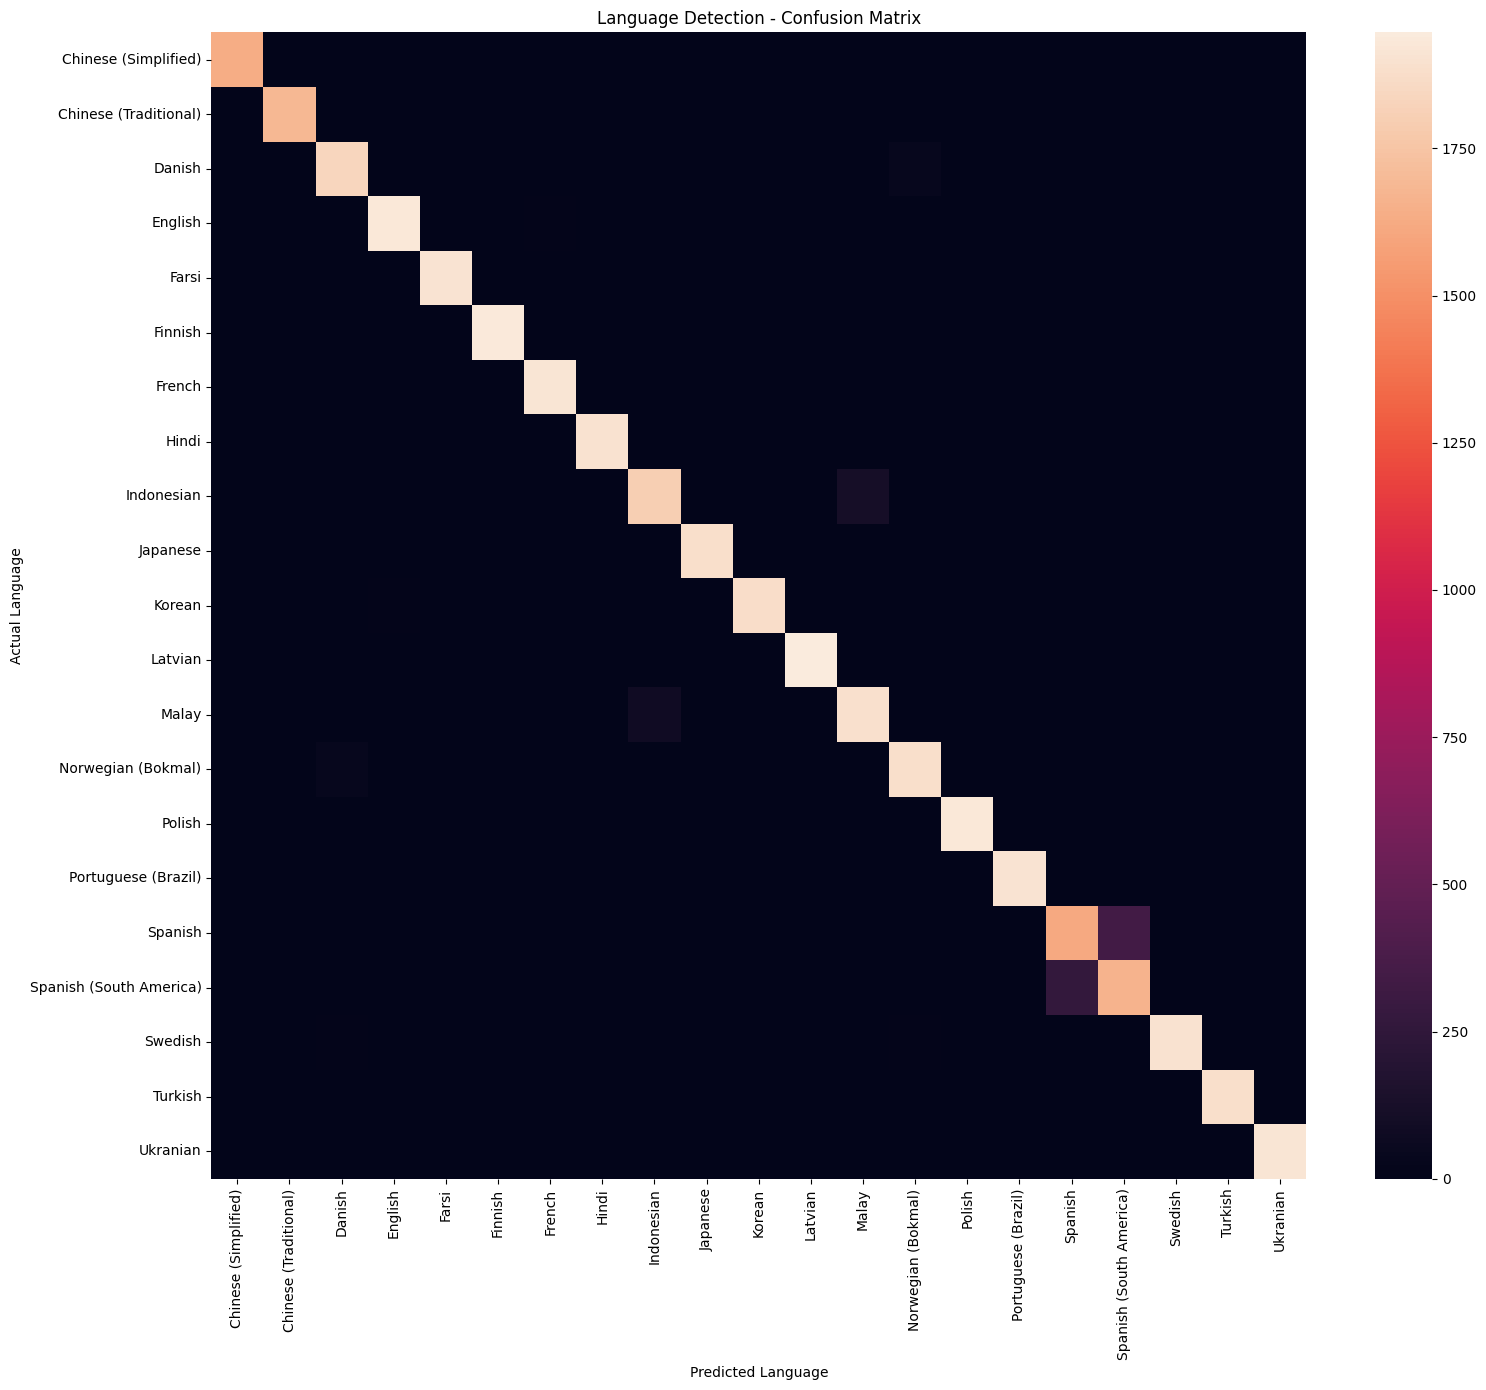

In [44]:
plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Language")
plt.ylabel("Actual Language")
plt.title("Language Detection - Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [45]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print("Overall Accuracy:")
print(f"{accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

Overall Accuracy:
97.35%

Classification Report:
                         precision    recall  f1-score   support

   Chinese (Simplified)     0.9994    0.9982    0.9988      1638
  Chinese (Traditional)     1.0000    0.9970    0.9985      1692
                 Danish     0.9772    0.9746    0.9759      1888
                English     0.9645    0.9913    0.9777      1944
                  Farsi     1.0000    0.9984    0.9992      1909
                Finnish     0.9990    0.9974    0.9982      1942
                 French     0.9871    0.9933    0.9902      1929
                  Hindi     1.0000    0.9995    0.9997      1897
             Indonesian     0.9558    0.9368    0.9462      1916
               Japanese     0.9995    0.9995    0.9995      1882
                 Korean     0.9995    0.9947    0.9971      1882
                Latvian     1.0000    0.9969    0.9985      1953
                  Malay     0.9440    0.9574    0.9507      1972
     Norwegian (Bokmal)     0.9741    0.

In [46]:
import os

os.makedirs(
    "/content/language_detection_model",
    exist_ok=True
)

In [47]:
import joblib

joblib.dump(
    model,
    "/content/language_detection_model/language_model.pkl"
)

print("Language model saved!")

Language model saved!


In [48]:
!pip install -q transformers sentencepiece accelerate

In [49]:
!pip install -q transformers sentencepiece accelerate

In [50]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(model_name)
translation_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("NLLB model loaded successfully!")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 4.85MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.46GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

NLLB model loaded successfully!


In [51]:
def translate_en_to_hi(text):

    tokenizer.src_lang = "eng_Latn"

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    translated_tokens = translation_model.generate(
        **inputs,
        forced_bos_token_id=tokenizer.convert_tokens_to_ids("hin_Deva"),
        max_length=128,
        num_beams=5
    )

    translated_text = tokenizer.batch_decode(
        translated_tokens,
        skip_special_tokens=True
    )[0]

    return translated_text

In [52]:
text = "I am learning machine learning."

translation = translate_en_to_hi(text)

print("Input       :", text)
print("Translation :", translation)

Input       : I am learning machine learning.
Translation : मैं मशीन लर्निंग सीख रहा हूँ।


In [53]:
import joblib

language_model = joblib.load(
    "/content/language_detection_model/language_model.pkl"
)

# Save the tfidf vectorizer before attempting to load it
# The tfidf object is created and fitted in cell StCNpSFYCtqn
# and should be in the kernel's memory.
joblib.dump(
    tfidf,
    "/content/language_detection_model/tfidf_vectorizer.pkl"
)

tfidf_vectorizer = joblib.load(
    "/content/language_detection_model/tfidf_vectorizer.pkl"
)

In [54]:
def detect_language(text):

    text_tfidf = tfidf_vectorizer.transform([text])

    detected_language = language_model.predict(
        text_tfidf
    )[0]

    return detected_language

In [55]:
text = "I am learning machine learning."

# Language Detection
detected_language = detect_language(text)

print("Detected Language:", detected_language)

# Translation
if detected_language == "English":

    translated_text = translate_en_to_hi(text)

    print("Translated Text:", translated_text)

Detected Language: English
Translated Text: मैं मशीन लर्निंग सीख रहा हूँ।


In [56]:
LANGUAGE_CODES = {
    "English": "eng_Latn",
    "Hindi": "hin_Deva",
    "French": "fra_Latn",
    "German": "deu_Latn",
    "Spanish": "spa_Latn",
    "Portuguese (Brazil)": "por_Latn",
    "Portuguese (EU)": "por_Latn",
    "Danish": "dan_Latn",
    "Indonesian": "ind_Latn",
    "Korean": "kor_Hang",
    "Finnish": "fin_Latn",
    "Polish": "pol_Latn",
    "Turkish": "tur_Latn",
    "Malay": "zsm_Latn",
    "Swedish": "swe_Latn",
    "Latvian": "lvs_Latn",
    "Japanese": "jpn_Jpan",
    "Farsi": "pes_Arab",
    "Ukranian": "ukr_Cyrl",
    "Romanian": "ron_Latn",
    "Russian": "rus_Cyrl",
    "Chinese (Simplified)": "zho_Hans",
    "Chinese (Traditional)": "zho_Hant",
    "Norwegian (Bokmal)": "nob_Latn",
}

In [57]:
def translate_to_hindi(text, detected_language):

    source_code = LANGUAGE_CODES.get(detected_language)

    if source_code is None:
        return "Language not supported for translation."

    tokenizer.src_lang = source_code

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    translated_tokens = translation_model.generate(
        **inputs,
        forced_bos_token_id=tokenizer.convert_tokens_to_ids("hin_Deva"),
        max_length=128,
        num_beams=5
    )

    return tokenizer.batch_decode(
        translated_tokens,
        skip_special_tokens=True
    )[0]

In [58]:
text = "I am learning machine learning."

# 1. Detect language
detected_language = detect_language(text)

print("Input:", text)
print("Detected Language:", detected_language)

# 2. Translate to Hindi
translated_text = translate_to_hindi(
    text,
    detected_language
)

print("Hindi Translation:", translated_text)

Input: I am learning machine learning.
Detected Language: English
Hindi Translation: मैं मशीन लर्निंग सीख रहा हूँ।


In [59]:
TARGET_LANGUAGES = {
    "Hindi": "hin_Deva",
    "English": "eng_Latn",
    "French": "fra_Latn",
    "Spanish": "spa_Latn",
    "German": "deu_Latn",
    "Japanese": "jpn_Jpan",
    "Korean": "kor_Hang",
    "Russian": "rus_Cyrl",
    "Chinese": "zho_Hans",
    "Portuguese": "por_Latn",
    "Turkish": "tur_Latn"
}

In [60]:
def translate_text(text, source_language, target_language):

    source_code = LANGUAGE_CODES.get(source_language)
    target_code = TARGET_LANGUAGES.get(target_language)

    if source_code is None:
        return "Source language is not supported."

    if target_code is None:
        return "Target language is not supported."

    tokenizer.src_lang = source_code

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    translated_tokens = translation_model.generate(
        **inputs,
        forced_bos_token_id=tokenizer.convert_tokens_to_ids(target_code),
        max_length=128,
        num_beams=5
    )

    return tokenizer.batch_decode(
        translated_tokens,
        skip_special_tokens=True
    )[0]

In [61]:
text = "I am learning machine learning."

result = translate_text(
    text,
    "English",
    "Hindi"
)

print(result)

मैं मशीन लर्निंग सीख रहा हूँ।


In [62]:
result = translate_text(
    text,
    "English",
    "French"
)

print(result)

Je suis en train d'apprendre l'apprentissage automatique.


In [63]:
result = translate_text(
    text,
    "English",
    "Japanese"
)

print(result)

私は機械学習を学びます.


In [64]:
def detect_and_translate(text, target_language):

    # Language Detection
    detected_language = detect_language(text)

    # Translation
    translated_text = translate_text(
        text,
        detected_language,
        target_language
    )

    return detected_language, translated_text

In [65]:
text = "I am learning machine learning."

detected, translated = detect_and_translate(
    text,
    "Hindi"
)

print("Input:", text)
print("Detected Language:", detected)
print("Target Language: Hindi")
print("Translation:", translated)

Input: I am learning machine learning.
Detected Language: English
Target Language: Hindi
Translation: मैं मशीन लर्निंग सीख रहा हूँ।


In [66]:
def translation_pipeline():

    text = input("Enter your sentence: ")

    print("\nAvailable Target Languages:")
    for i, lang in enumerate(TARGET_LANGUAGES.keys(), 1):
        print(f"{i}. {lang}")

    choice = int(input("\nSelect target language number: "))

    target_language = list(TARGET_LANGUAGES.keys())[choice - 1]

    # Language Detection
    detected_language = detect_language(text)

    print("\nDetected Language:", detected_language)
    print("Target Language:", target_language)

    # Translation
    translated_text = translate_text(
        text,
        detected_language,
        target_language
    )

    print("Translation:", translated_text)

In [67]:
translation_pipeline()

Enter your sentence: I am a Boy

Available Target Languages:
1. Hindi
2. English
3. French
4. Spanish
5. German
6. Japanese
7. Korean
8. Russian
9. Chinese
10. Portuguese
11. Turkish

Select target language number: 1

Detected Language: Portuguese (Brazil)
Target Language: Hindi
Translation: मैं एक लड़का हूँ


In [68]:
translation_pipeline()

Enter your sentence: I am learning machine learning

Available Target Languages:
1. Hindi
2. English
3. French
4. Spanish
5. German
6. Japanese
7. Korean
8. Russian
9. Chinese
10. Portuguese
11. Turkish

Select target language number: 1

Detected Language: English
Target Language: Hindi
Translation: मैं मशीन लर्निंग सीख रहा हूँ


In [69]:
text = "i am a boy"

text_tfidf = tfidf_vectorizer.transform([text])

probabilities = language_model.predict_proba(text_tfidf)[0]

results = sorted(
    zip(language_model.classes_, probabilities),
    key=lambda x: x[1],
    reverse=True
)

for language, probability in results[:5]:
    print(f"{language}: {probability:.4f}")

Portuguese (Brazil): 0.1785
Turkish: 0.1633
Polish: 0.0778
Malay: 0.0719
English: 0.0702


In [70]:
language_model = LogisticRegression(
    max_iter=2000,
    C=5,
    solver="saga",
    random_state=42
)

language_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(C=5, max_iter=2000, random_state=42, solver='saga')

In [ ]:
text = "i am a boy"

text_tfidf = tfidf.transform([text])

prediction = language_model.predict(text_tfidf)[0]

print("Input:", text)
print("Detected Language:", prediction)